# Packages

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt

# Loading the data

This notebook contains the code to generate the plots for the thymus DN cells dataset, meaning figure 7 a, b, c, and d. For this purpose we need to load the thymus DN cells + thymus Vg6 dataset, which is dowloadable at: **provide link** 

In [2]:
thymus_dn_vg6 = sc.read_h5ad('/media/david/DiskExtension/Collaborations/GFI1_Canada/datasets_publication_v1/thymus_dn_vg6.h5ad')

thymus_dn_vg6

AnnData object with n_obs × n_vars = 29236 × 18307
    obs: 'sorted_cell_type', 'batch', 'organ', 'hto_classification', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'genotype', 'mouse', 'cell_type'
    var: 'ribo', 'gm', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'cell_type_updated_colors', 'draw_graph', 'genotype_colors', 'hvg', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'umap'
    obsm: 'X_draw_graph_fa', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'log1p_norm', 'raw_counts', 'scaled'
    obsp: 'connectivities', 'distances'

# Figure 7

## a)

In [8]:
colors = [
    '#66c5cc','#f6cf71','#f89c74',
    '#dcb0f2','#87c55f','#9eb9f3',
    '#fe88b1','#c9db74','#8be0a4',
    '#b497e7','#d3b484','#b3b3b3',
    '#89fade','#817157'
]
cluster_colors = {
    f'{i}': colors[i] for i in range(14)
}

Text(0.5, 1.0, 'Clusters')

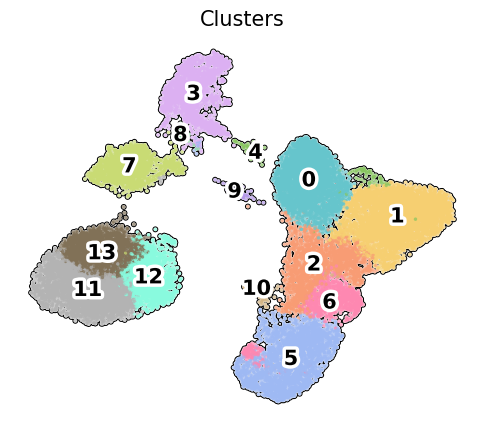

In [9]:
fig, axes = plt.subplots(1,1, figsize=(6,5))

sc.pl.umap(
    thymus_dn_vg6,
    color='leiden',
    legend_loc='on data',
    palette=cluster_colors,
    size=25,
    add_outline=True,
    legend_fontoutline=5,
    legend_fontsize=15,
    frameon=False,
    ax=axes, show=False,
)

axes.set_title(
    'Clusters',
    fontsize=15
)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/thymus_dn_data/thymus_dn_gd_umap_cluster.pdf',
#     bbox_inches='tight'
# )

## b)

In [10]:
genotype_colors = {
    'ko': '#008000',
    'wt': '#a0a0a4'
}

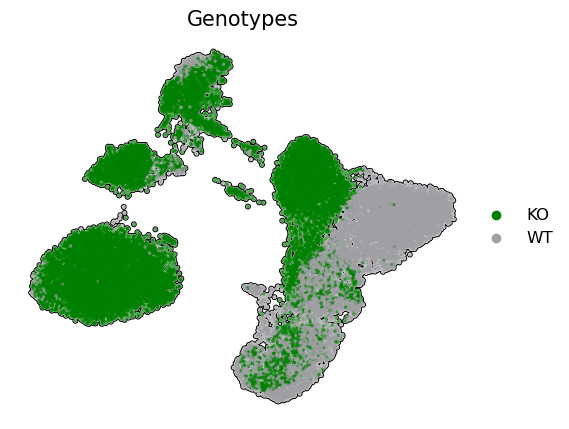

In [12]:
fig, axes = plt.subplots(1,1, figsize=(6,5))

sc.pl.umap(
    thymus_dn_vg6,
    color='genotype',
    palette=genotype_colors,
    size=25,
    add_outline=True,
    legend_fontoutline=5,
    legend_fontsize=15,
    frameon=False,
    ax=axes, show=False,
)

axes.set_title(
    'Genotypes',
    fontsize=15
)

handles, labels = axes.get_legend_handles_labels()

labels = [label.upper() for label in labels]

axes.legend(
    handles,
    labels,
    loc='center right',
    bbox_to_anchor=(1.2, 0.5),
    title=None,
    fontsize=12,
    title_fontsize=15,
    frameon=False
)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/thymus_dn_data/thymus_dn_gd_umap_genotype.pdf',
#     bbox_inches='tight'
# )

## c)

In [13]:
cell_type_colors = {
    'Trgv6+': '#a6cee3',
    'Rorc+ DN1d': '#ff7f00',
    'DN3a --> DN3b': '#e31a1c',
    'DN1/DN2': '#b2df8a',
    'Il2rb+ DN1e': '#33a02c',
    'DN3a': '#fb9a99',
    'Rorc+ DN1e': '#1f78b4',
    'DN3b': '#fdbf6f',
}

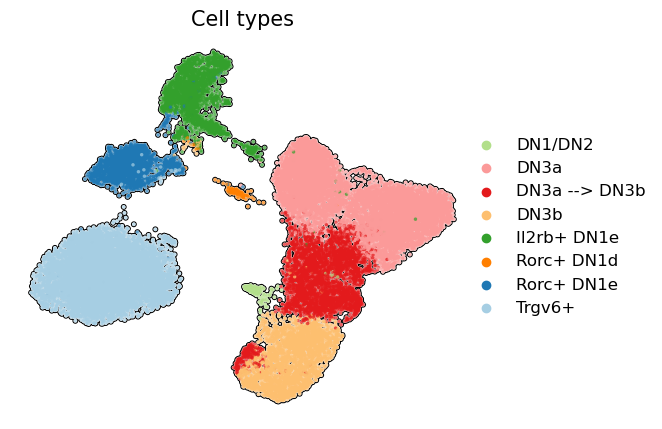

In [15]:
fig, axes = plt.subplots(1,1, figsize=(6,5))

sc.pl.umap(
    thymus_dn_vg6,
    color='cell_type',
    palette=cell_type_colors,
    size=25,
    add_outline=True,
    legend_fontoutline=5,
    legend_fontsize=15,
    frameon=False,
    ax=axes, show=False,
)

axes.set_title(
    'Cell types',
    fontsize=15
)

axes.legend(
    loc='center right',
    bbox_to_anchor=(1.4, 0.5),
    title=None,
    fontsize=12,
    title_fontsize=15,
    frameon=False
)

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/thymus_dn_data/thymus_dn_gd_umap_celltypes.pdf',
#     bbox_inches='tight'
# )

## d)

In [16]:
df_cluster_medioids = pd.DataFrame(thymus_dn_vg6.obsm['X_umap'], columns=['umap_1', 'umap_2'], index=thymus_dn_vg6.obs_names)
clusters = sc.get.obs_df(thymus_dn_vg6, keys=['leiden'])

df_cluster_medioids = df_cluster_medioids.merge(clusters, left_index=True, right_index=True)

cluster_medioids = (
    df_cluster_medioids
    .groupby('leiden')
    .median()
    .to_numpy()
)

<positron-console-cell-16>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


/home/david/anaconda3/envs/skin_development/lib/python3.12/site-packages/scanpy/plotting/_tools/paga.py:937: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sct = ax.scatter(


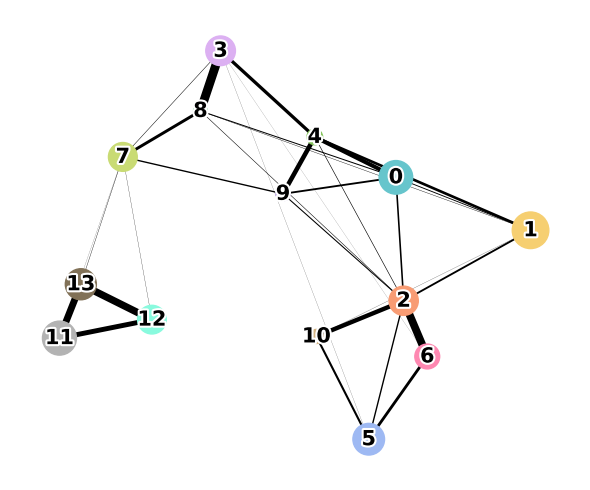

In [20]:
fig, axes = plt.subplots(1,1, figsize=(6,5))

sc.pl.paga(
    thymus_dn_vg6,
    color='leiden',
    frameon=False,
    show=False,
    ax=axes,
    title=None,
    pos=cluster_medioids,
    fontoutline=3,
    fontsize=15,
    node_size_scale=3,
    cmap=cluster_colors
)


plt.tight_layout()

# plt.savefig(
#     '/media/david/DiskExtension/Collaborations/GFI1_Canada/figures_paper_v1/thymus_dn_data/thymus_dn_gd_paga_cluster.pdf',
#     bbox_inches='tight'
# )